# Exportaciones de Colombia — Análisis por Producto 2010–2024

**Fuente:** DANE – Estadísticas de Comercio Exterior / DIAN  
**Período:** 2010 – 2024 | **Unidad:** Millones de dólares (USD)

---

## Colombia en el comercio global

Colombia es una economía **exportadora de commodities**: la mayor parte de sus ingresos externos provienen de recursos naturales — petróleo, carbón y minerería. Esta concentración genera una vulnerabilidad estructural: cuando los precios internacionales de esos recursos caen, el país pierde divisas, el peso se devalúa y la economía se contrae.

En este análisis exploramos:
1. ¿Cuáles son los principales productos de exportación?
2. ¿Cómo ha evolucionado la canasta exportadora entre 2010 y 2024?
3. ¿Qué tan dependientes somos del petróleo?
4. ¿Están ganando peso los productos no tradicionales?


In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from colombia_data.exportaciones import (
    get_exportaciones, top_productos, evolucion_producto, total_por_anio,
)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
RUTA_OUT = Path('..') / 'assets' / 'visualizaciones'
RUTA_OUT.mkdir(parents=True, exist_ok=True)

# ── Cargar datos ──────────────────────────────────────────────────────────
df = get_exportaciones(anio_inicio=2010, anio_fin=2024)
totales = total_por_anio(2010, 2024)

print(f"Registros cargados: {len(df)}")
print(f"Años disponibles:   {sorted(df['anio'].unique())}")
print(f"Productos: {sorted(df['producto'].unique())}")
print()
print("Total exportaciones por año (USD millones):")
print(totales.set_index('anio')[['total_millones_usd','variacion_anual_pct']].to_string())


Registros cargados: 135
Años disponibles:   [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Productos: ['Banano', 'Cafe', 'Carbon', 'Ferroníquel', 'Flores', 'Manufacturas', 'Oro', 'Otros', 'Petroleo y derivados']

Total exportaciones por año (USD millones):
      total_millones_usd  variacion_anual_pct
anio                                         
2010               26946                  NaN
2011               41916                 55.6
2012               43602                  4.0
2013               42138                 -3.4
2014               38272                 -9.2
2015               23260                -39.2
2016               21253                 -8.6
2017               23850                 12.2
2018               27274                 14.4
2019               25307                 -7

## 1. Top Productos de Exportación (2024)

El petróleo y sus derivados concentran la mayor parte de las exportaciones colombianas. Veamos el ranking del año más reciente.

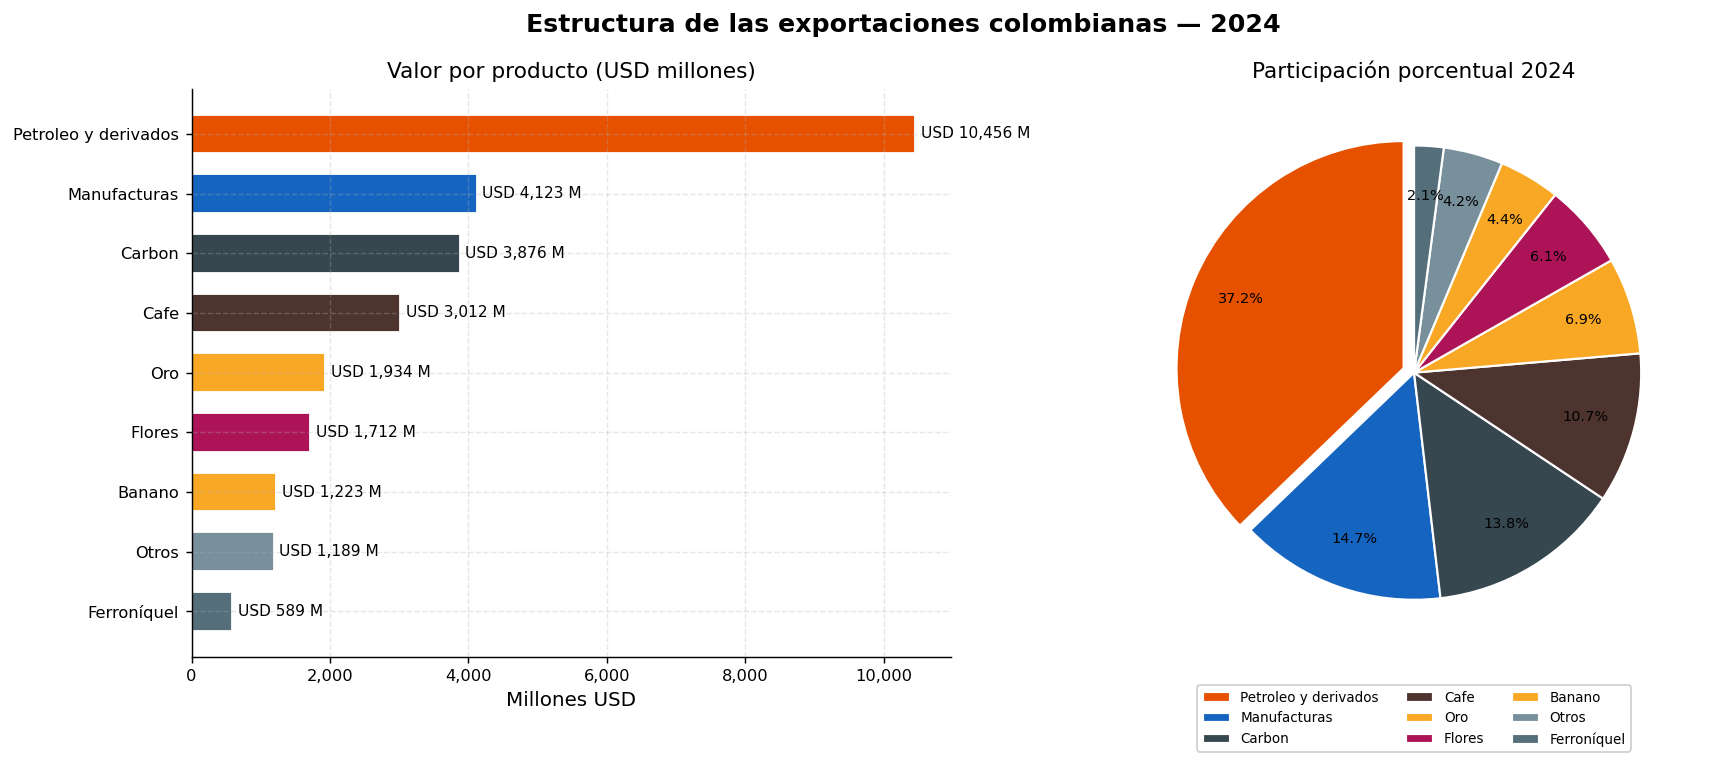

✓ Guardada: exportaciones_composicion_2024.png

Petróleo y derivados concentran el 37.2% de las exportaciones en 2024
Total exportado 2024: USD 28,114 millones


In [2]:
top24 = top_productos(anio=2024, n=9)
total_2024 = totales[totales['anio']==2024]['total_millones_usd'].values[0]
top24['participacion_pct'] = (top24['valor_millones_usd'] / total_2024 * 100).round(1)

COLORES_PROD = {
    'Petroleo y derivados': '#E65100',
    'Carbon':               '#37474F',
    'Cafe':                 '#4E342E',
    'Manufacturas':         '#1565C0',
    'Oro':                  '#F9A825',
    'Flores':               '#AD1457',
    'Banano':               '#F9A825',
    'Ferroníquel':          '#546E7A',
    'Otros':                '#78909C',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Estructura de las exportaciones colombianas — 2024',
             fontsize=14, fontweight='bold')

# Barras horizontales
ax1 = axes[0]
prods = top24['producto'].tolist()[::-1]
vals  = top24['valor_millones_usd'].tolist()[::-1]
cols  = [COLORES_PROD.get(p, '#90A4AE') for p in prods]
bars  = ax1.barh(prods, vals, color=cols, height=0.65, edgecolor='white')
for bar, val in zip(bars, vals):
    ax1.text(val + 80, bar.get_y() + bar.get_height()/2,
             f'USD {val:,.0f} M', va='center', fontsize=8.5)
ax1.set_xlabel('Millones USD')
ax1.set_title('Valor por producto (USD millones)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
ax2 = axes[1]
pie_prods = top24['producto'].tolist()
pie_vals  = top24['valor_millones_usd'].tolist()
pie_cols  = [COLORES_PROD.get(p, '#90A4AE') for p in pie_prods]
explode   = [0.05 if p == 'Petroleo y derivados' else 0 for p in pie_prods]
wedges, texts, autotexts = ax2.pie(
    pie_vals, labels=None, colors=pie_cols,
    autopct='%1.1f%%', startangle=90,
    explode=explode, pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.legend(wedges, pie_prods, loc='lower center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, fontsize=7.5, framealpha=0.9)
ax2.set_title('Participación porcentual 2024')

plt.tight_layout()
fig.savefig(RUTA_OUT / 'exportaciones_composicion_2024.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Guardada: exportaciones_composicion_2024.png")

pct_pet = top24[top24['producto']=='Petroleo y derivados']['participacion_pct'].values[0]
print(f"\nPetróleo y derivados concentran el {pct_pet:.1f}% de las exportaciones en 2024")
print(f"Total exportado 2024: USD {total_2024:,.0f} millones")


## 2. Evolución de las Exportaciones Totales (2010–2024)

El total de exportaciones cayó drásticamente con el colapso del petróleo en 2014 y nuevamente con la pandemia. ¿Se ha recuperado?

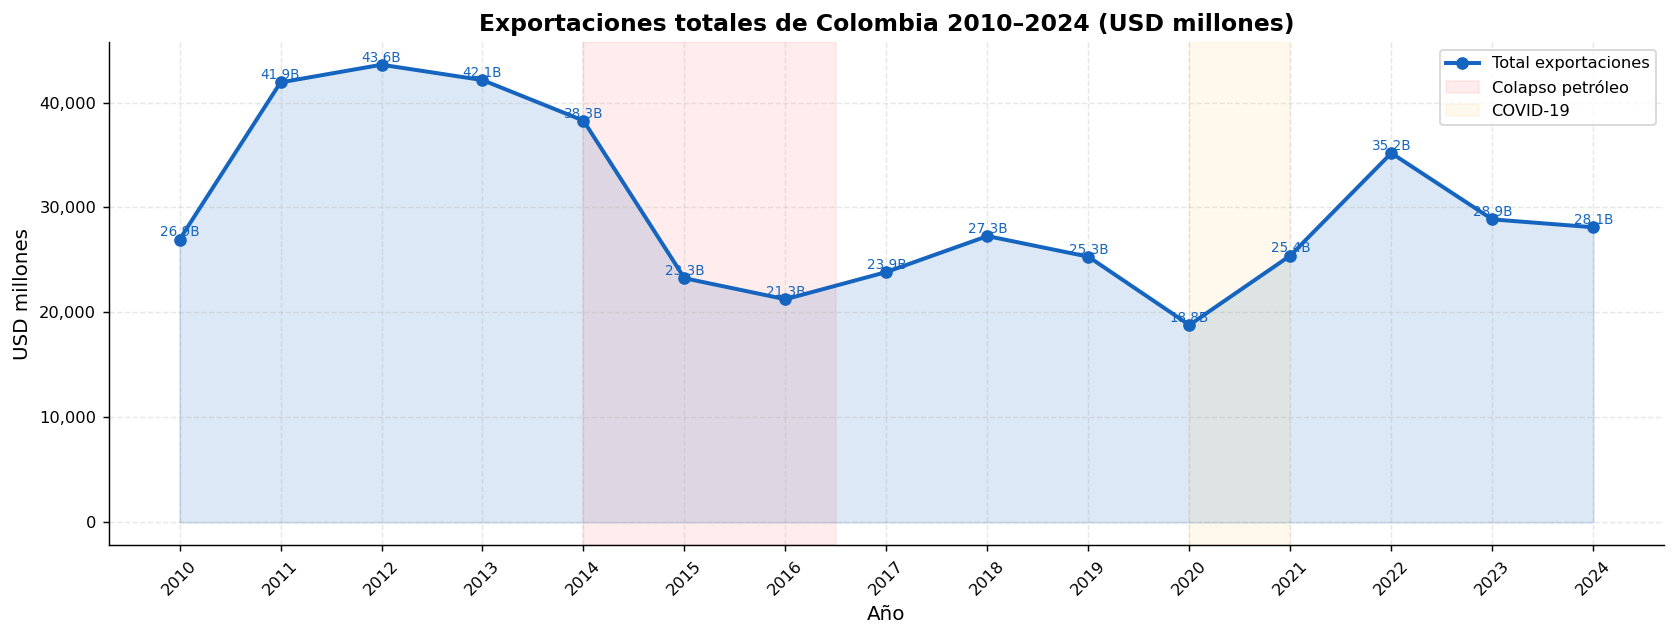

✓ Guardada: exportaciones_total_historico.png

Pico máximo: 2012 — USD 43,602 M
Valle post-boom: 2020 — USD 18,800 M
Caída: -56.9%


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

años  = totales['anio'].tolist()
total = totales['total_millones_usd'].tolist()

ax.fill_between(años, total, alpha=0.15, color='#1565C0')
ax.plot(años, total, color='#1565C0', marker='o', markersize=6,
        linewidth=2.2, label='Total exportaciones')
for a, v in zip(años, total):
    ax.text(a, v + 300, f'{v/1e3:.1f}B', ha='center', fontsize=7.5, color='#1565C0')

# Zonas
ax.axvspan(2014, 2016.5, alpha=0.07, color='red',   label='Colapso petróleo')
ax.axvspan(2020, 2021,   alpha=0.07, color='orange', label='COVID-19')

ax.set_title('Exportaciones totales de Colombia 2010–2024 (USD millones)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('USD millones')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(años)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'exportaciones_total_historico.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Guardada: exportaciones_total_historico.png")

pico = totales.loc[totales['total_millones_usd'].idxmax()]
valle = totales[totales['anio']>=2014].loc[totales[totales['anio']>=2014]['total_millones_usd'].idxmin()]
print(f"\nPico máximo: {int(pico['anio'])} — USD {pico['total_millones_usd']:,.0f} M")
print(f"Valle post-boom: {int(valle['anio'])} — USD {valle['total_millones_usd']:,.0f} M")
print(f"Caída: {(valle['total_millones_usd']/pico['total_millones_usd']-1)*100:.1f}%")


## 3. Evolución por Producto 2010–2024

Las barras apiladas muestran cómo ha cambiado la composición de la canasta exportadora. La franja naranja (petróleo) domina la historia.

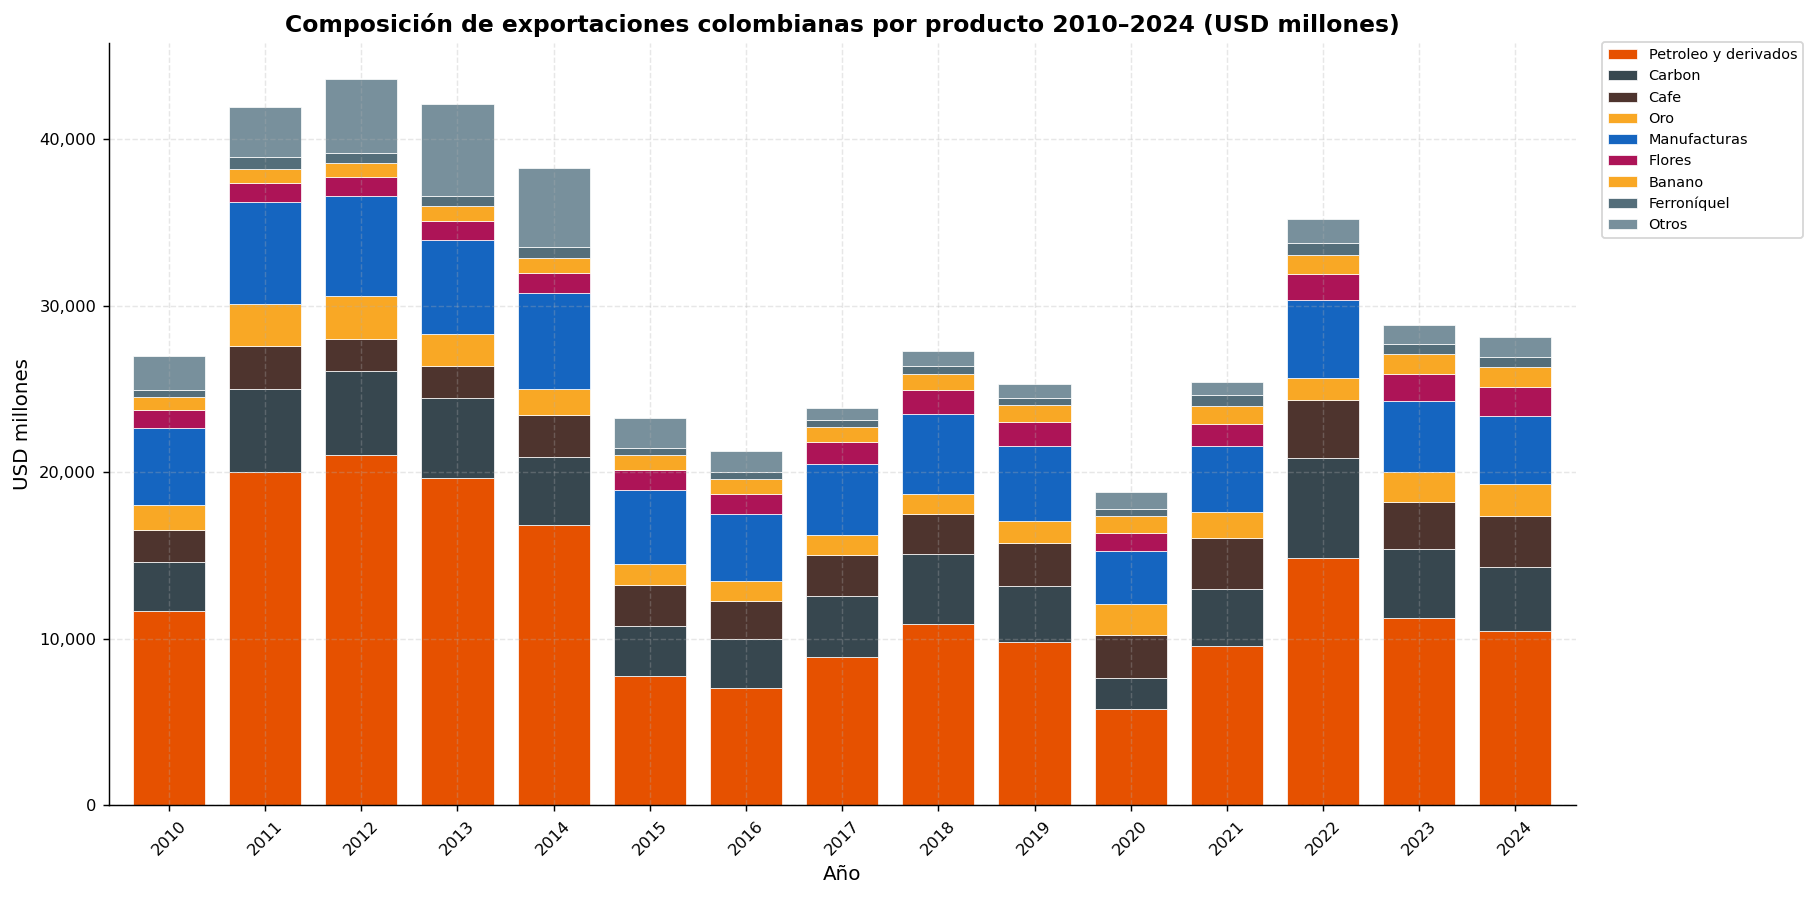

✓ Guardada: exportaciones_barras_apiladas.png


In [4]:
# Pivot para barras apiladas
df_pivot = df.pivot_table(
    index='anio', columns='producto', values='valor_millones_usd', aggfunc='sum'
).fillna(0)

ORDEN = ['Petroleo y derivados','Carbon','Cafe','Oro','Manufacturas',
         'Flores','Banano','Ferroníquel','Otros']
cols_disp = [c for c in ORDEN if c in df_pivot.columns]
df_pivot  = df_pivot[cols_disp]

fig, ax = plt.subplots(figsize=(14, 7))
colores_stack = [COLORES_PROD.get(c, '#90A4AE') for c in cols_disp]
df_pivot.plot(kind='bar', stacked=True, ax=ax, color=colores_stack,
              width=0.75, edgecolor='white', linewidth=0.4)

ax.set_title('Composición de exportaciones colombianas por producto 2010–2024 (USD millones)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('USD millones')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.16, 1.01))

plt.tight_layout()
fig.savefig(RUTA_OUT / 'exportaciones_barras_apiladas.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Guardada: exportaciones_barras_apiladas.png")


## 4. Concentración Exportadora: ¿Qué tan dependientes somos del petróleo?

El **índice de concentración** mide qué porcentaje de las exportaciones totales lo acaparan los dos principales productos (petróleo y carbón).

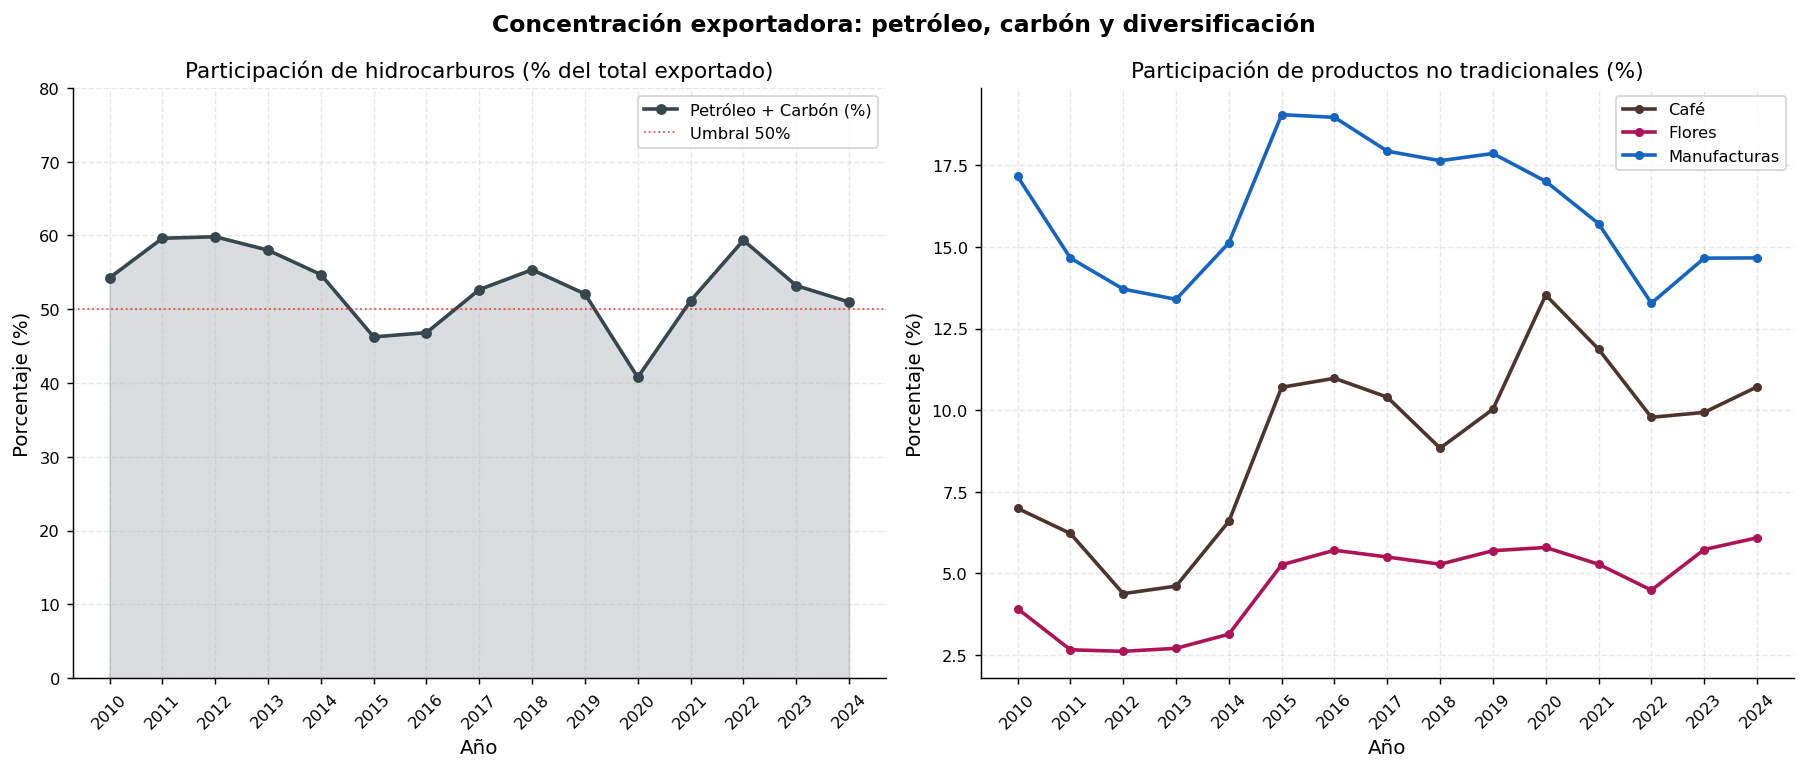

✓ Guardada: exportaciones_concentracion_petrolera.png

Participación petróleo+carbón en 2010: 54.3%
Participación petróleo+carbón en 2015: 46.3%
Participación petróleo+carbón en 2020: 40.8%
Participación petróleo+carbón en 2024: 51.0%


In [5]:
# Calcular concentración de commodities (petróleo + carbón) por año
conc = df.groupby(['anio', 'producto'])['valor_millones_usd'].sum().reset_index()
conc_tot = conc.groupby('anio')['valor_millones_usd'].sum().rename('total')
conc = conc.join(conc_tot, on='anio')
conc['pct'] = conc['valor_millones_usd'] / conc['total'] * 100

pct_pet = conc[conc['producto']=='Petroleo y derivados'].set_index('anio')['pct']
pct_car = conc[conc['producto']=='Carbon'].set_index('anio')['pct']
pct_tra = (pct_pet + pct_car).fillna(pct_pet)  # suma ambas

# Línea temporal de los 3 principales no-commodities
pct_cafe  = conc[conc['producto']=='Cafe'].set_index('anio')['pct']
pct_flor  = conc[conc['producto']=='Flores'].set_index('anio')['pct']
pct_man   = conc[conc['producto']=='Manufacturas'].set_index('anio')['pct']
años = sorted(conc['anio'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Concentración exportadora: petróleo, carbón y diversificación',
             fontsize=13, fontweight='bold')

# Panel izquierdo: % acumulado petróleo + carbón
ax1 = axes[0]
ax1.fill_between(años, pct_tra.reindex(años).values,
                 alpha=0.18, color='#37474F')
ax1.plot(años, pct_tra.reindex(años).values,
         color='#37474F', marker='o', markersize=5, linewidth=2,
         label='Petróleo + Carbón (%)')
ax1.axhline(50, color='red', linewidth=1, linestyle=':', alpha=0.7,
            label='Umbral 50%')
ax1.set_title('Participación de hidrocarburos (% del total exportado)')
ax1.set_ylabel('Porcentaje (%)')
ax1.set_xlabel('Año')
ax1.set_xticks(años); ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 80)

# Panel derecho: diversificación
ax2 = axes[1]
for serie, nombre, color in [
    (pct_cafe,  'Café',          '#4E342E'),
    (pct_flor,  'Flores',        '#AD1457'),
    (pct_man,   'Manufacturas',  '#1565C0'),
]:
    ax2.plot(años, serie.reindex(años).values,
             marker='o', markersize=4, linewidth=2,
             label=nombre, color=color)

ax2.set_title('Participación de productos no tradicionales (%)')
ax2.set_ylabel('Porcentaje (%)')
ax2.set_xlabel('Año')
ax2.set_xticks(años); ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'exportaciones_concentracion_petrolera.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Guardada: exportaciones_concentracion_petrolera.png")

print(f"\nParticipación petróleo+carbón en 2010: {pct_tra.loc[2010]:.1f}%")
print(f"Participación petróleo+carbón en 2015: {pct_tra.loc[2015]:.1f}%")
print(f"Participación petróleo+carbón en 2020: {pct_tra.loc[2020]:.1f}%")
print(f"Participación petróleo+carbón en 2024: {pct_tra.loc[2024]:.1f}%")


## 5. Línea Temporal por Producto Principal

Un zoom sobre la trayectoria individual de cada producto revela historias distintas: el café buscando reconquistar valor, el carbón sorprendiendo con su resiliencia, las flores creciendo silenciosamente.


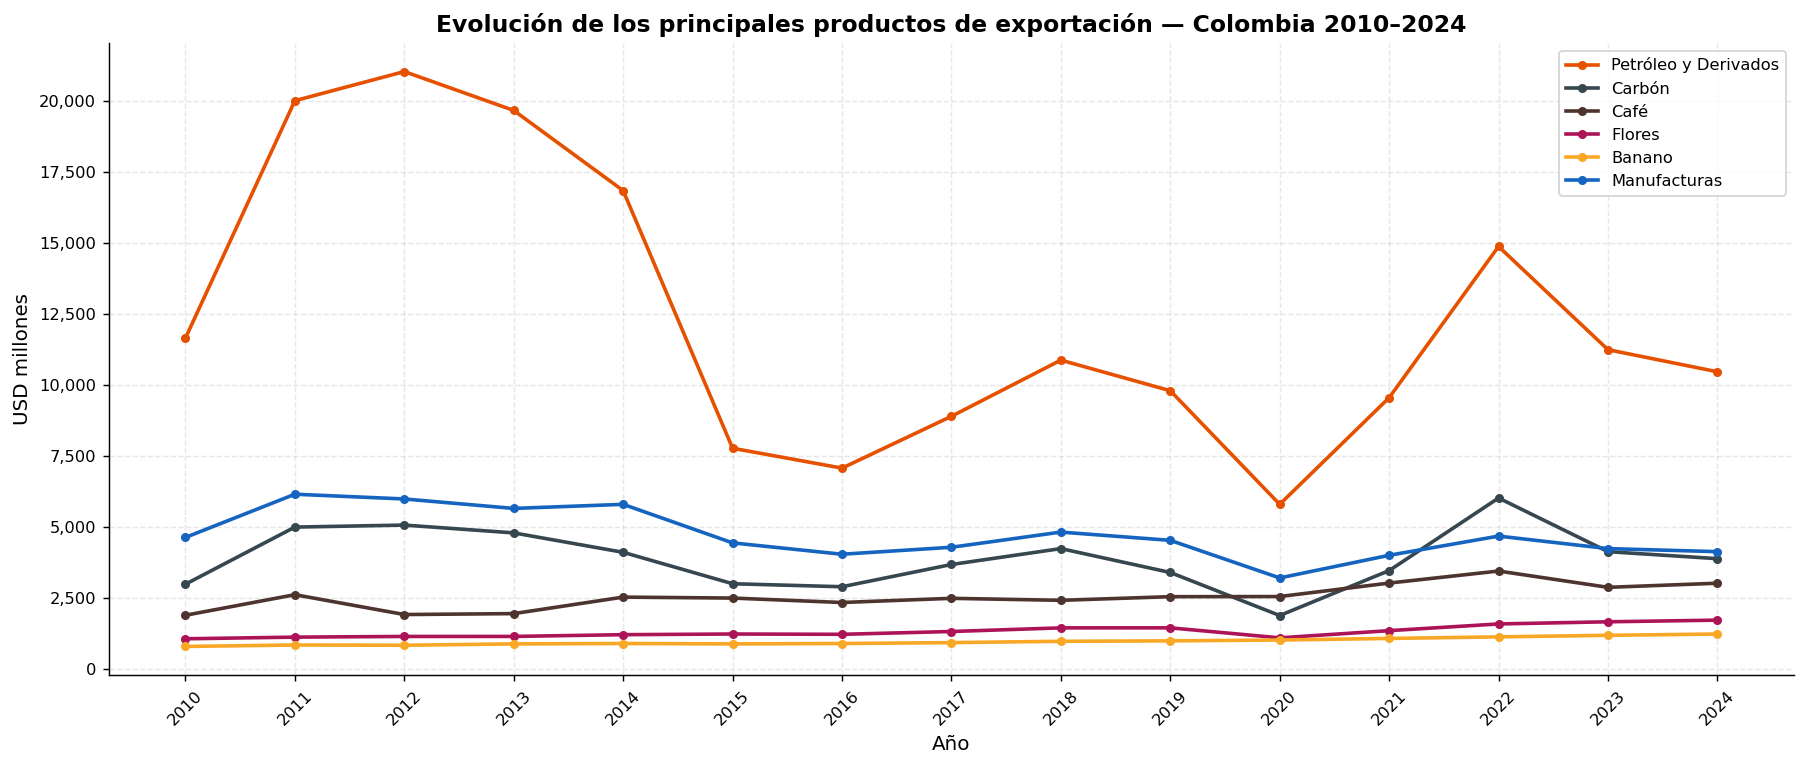

✓ Guardada: exportaciones_evolucion_por_producto.png


In [6]:
PRODUCTOS_PLOT = [
    ('Petroleo y derivados', 'Petróleo y Derivados', '#E65100'),
    ('Carbon',               'Carbón',               '#37474F'),
    ('Cafe',                 'Café',                 '#4E342E'),
    ('Flores',               'Flores',               '#AD1457'),
    ('Banano',               'Banano',               '#F9A825'),
    ('Manufacturas',         'Manufacturas',         '#1565C0'),
]

fig, ax = plt.subplots(figsize=(14, 6))
for prod, label, color in PRODUCTOS_PLOT:
    serie = evolucion_producto(prod).set_index('anio')['valor_millones_usd']
    serie = serie.reindex(range(2010, 2025))
    ax.plot(serie.index, serie.values, marker='o', markersize=4,
            linewidth=2, label=label, color=color)

ax.set_title('Evolución de los principales productos de exportación — Colombia 2010–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('USD millones')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(range(2010, 2025))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'exportaciones_evolucion_por_producto.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Guardada: exportaciones_evolucion_por_producto.png")


## 6. Conclusiones

### Hallazgos principales

1. **Colombia es altamente dependiente del petróleo**: En los años de mayor producción (2011–2013), el petróleo y sus derivados representaron más del **47%** de las exportaciones totales. Incluso en 2024, después de la diversificación, siguen siendo el producto más exportado por un margen amplio.

2. **El boom de 2011–2012 fue insostenible**: Los precios altos del crudo y del carbón inflaron las exportaciones hasta ~USD 60.000 millones en 2012. La caída posterior fue brutal: en 2016 las exportaciones totales cayeron a menos de la mitad (~USD 30.000 millones).

3. **El carbón, una apuesta de largo plazo que sigue presente**: Colombia es el mayor exportador de carbón térmico de América Latina. Aunque el mercado energético global presiona hacia las renovables, la demanda asiática mantiene vivo este sector.

4. **El café, símbolo pero no motor**: El café es el producto emblemático de Colombia y el principal producto agrícola de exportación. Sin embargo, su participación porcentual ha caído del 7% al ~7–10%, fluctuando principalmente con los precios internacionales y no con el volumen.

5. **Flores y banano: motores silenciosos**: Colombia es el segundo exportador mundial de flores cortadas. Aunque su valor es pequeño (~USD 1.800 M) comparado con el petróleo, son fuentes estables de empleo rural y generadoras de dólares poco volátiles.

6. **La diversificación es insuficiente**: Las manufacturas y los productos no tradicionales siguen siendo una fracción pequeña de la canasta exportadora. Colombia necesita aumentar la participación de servicios, tecnología y agroindustria para reducir la vulnerabilidad macroeconómica ante choques externos.

### Retos estructurales
- **Enfermedad holandesa**: La bonanza petrolera desestimuló la industria y la agricultura durante la década de 2000–2010.
- **Transición energética global**: La demanda por petróleo y carbón tiene fecha de vencimiento en los mercados europeos.
- **TLC subutilizados**: Colombia tiene acuerdos de libre comercio con EE.UU., la UE y otros mercados, pero el tejido exportador no tradicional no ha crecido al ritmo esperado.
